# <span style="color:black; font-weight:bold;">Cross-modal alignment and diagonal integration dorsal tongue Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-modal dorsal tongue data used in the tutorial are available at [merfish_rna.h5ad](https://drive.google.com/file/d/1IQz6AKhiJo0ROtrSbWvO7oEJ09SKwX6v/view?usp=sharing) and [pcf_protein.h5ad](https://drive.google.com/file/d/1wPWf2If9r---8trKl8_8CCgQNeOczLiw/view?usp=sharing). The raw data is from [SAME](https://www.biorxiv.org/content/10.1101/2025.07.12.664419v2).
In this tutorial we apply MAPS to align and integrate MERFISH and PCF dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">MERFISH(ST)</span>: 3608 cells and 300 genes   
+ <span style="color:black; font-weight:bold;">PCF(SP)</span>: 4671 cells and 30 protein 

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,prepare_paired_inputs,create_new_color_dict
from MAPS.modal_integration import COI
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-modal dorsal tongue data (MERFISH-RNA and PCF-protein)</span>
+ To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/tongue/merfish_rna.h5ad')
source_adata.obs['batch']='MERFISH(ST)'
sc.pp.normalize_total(source_adata,inplace=True)
sc.pp.log1p(source_adata)

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/tongue/pcf_protein.h5ad')
target_adata.obs['batch']='PCF(SP)'

### Rotate and translate the MERFISH data

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=12,dx=15000,dy=2300)

## <span style="color:black; font-weight:bold;">Spatial mapping of the dorsal tongue before alignment</span>

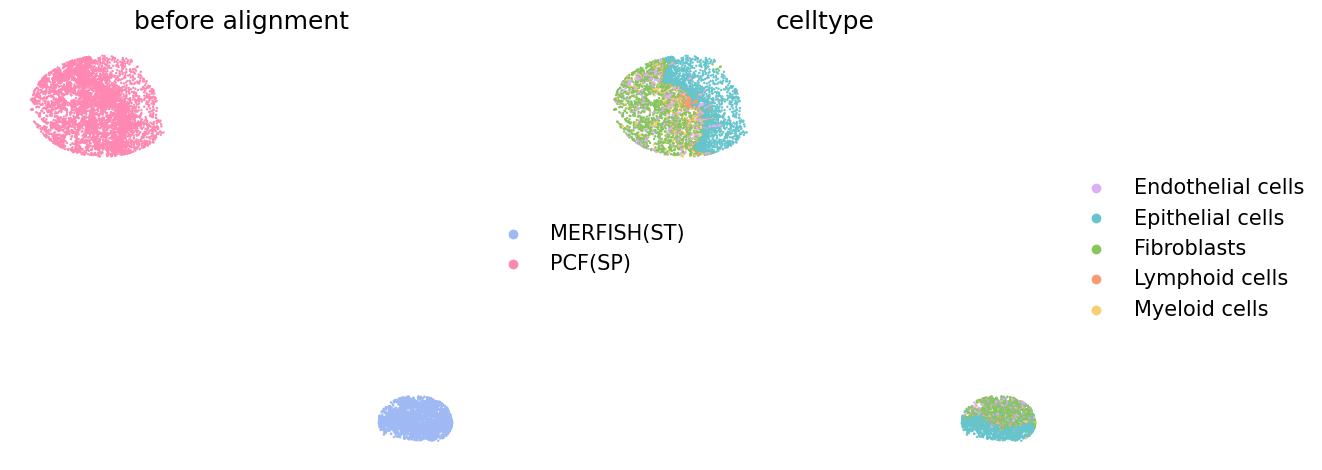

In [6]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
color_dict1=create_new_color_dict(adata,cat_key='batch',skip_default_colors=5)
color_dict2=create_new_color_dict(adata,cat_key='celltype',skip_default_colors=0)
color_dict = color_dict1 | color_dict2

sc.pl.embedding(adata=adata, basis='spatial',color=['batch','celltype'],title='before alignment',size=12,frameon=False,palette=color_dict)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=2000, sample_size=10000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████| 2000/2000 [00:04<00:00, 443.66it/s, Loss=20.55, Scale=1.958, Rot=123.41°, Trans=(-7601.7, 10691.8)]


Peak GPU memory usage: 0.220 GB
Scale factor: 1.958, Rotation angle: 123.59°, Translation (x, y): (-7602.29, 10691.16)
CPU times: user 5.17 s, sys: 620 ms, total: 5.79 s
Wall time: 5.99 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the dorsal tongue after alignment</span>

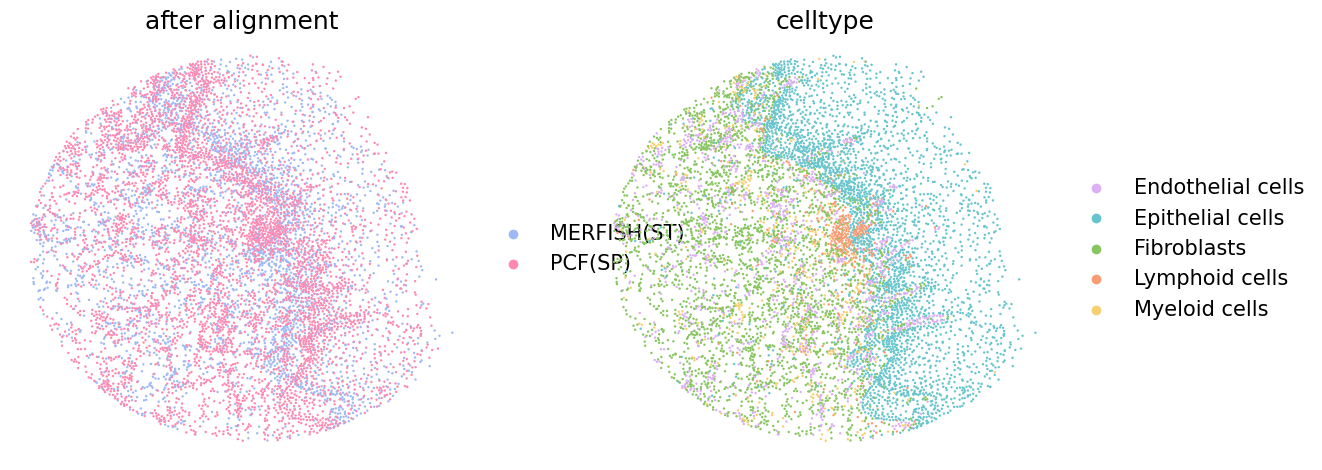

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','celltype'],title='after alignment',size=12,frameon=False,palette=color_dict)

## <span style="color:black; font-weight:bold;">Compute the cross-slice connection index matrix</span> 
### <span style="color:black; font-weight:bold;">Parameters</span> 
+ k_intra: K nearest neighbors within slice   
+ k_inter: K nearest neighbors between slices

In [9]:
source_adata.obsm['feat']=source_adata.X
target_adata.obsm['feat']=target_adata.X
graph1, graph2, idx_1_to_2 = prepare_paired_inputs(source_adata=source_adata, target_adata=target_adata, k_intra=5, k_inter=5, device=device)

## <span style="color:black; font-weight:bold;">Initialize the diagonal integration model</span> 

In [10]:
model = COI(in_channels1=graph1.features.shape[1],in_channels2=graph2.features.shape[1], out_channels=32)

## <span style="color:black; font-weight:bold;">Train diagonal integration model</span> 
### <span style="color:black; font-weight:bold;">Parameters</span> 
+ epochs: Training ephchs  
+ device: Training devic  
+ seed: Random seede

In [11]:
model.Train(graph1,graph2,idx_1_to_2,epochs=2000,lr=1e-3,device=device,seed=7)

Cross-modal integration: 100%|███████| 2000/2000 [00:12<00:00, 161.39it/s, Epoch=1999, Loss=0.251, Loss1=0.031, Loss2=0.173, Loss3=0.034, Loss4=0.003]


## <span style="color:black; font-weight:bold;">Output the reconstructed expression matrix and embedding</span> 

In [12]:
embedding1, embedding2,reconstructed1,reconstructed2 = model.get_embedding(graph1,graph2,idx_1_to_2)

In [13]:
source_adata.obsm['MAPS']=embedding1
target_adata.obsm['MAPS']=embedding2
source_adata.layers['rec']=reconstructed1
target_adata.layers['rec']=reconstructed2

## <span style="color:black; font-weight:bold;">Downstream analysis (kmeans and UMAP)</span> 

In [14]:
from sklearn.cluster import KMeans
adata=sc.concat([source_adata,target_adata],join='inner')

#leiden umap
sc.pp.neighbors(adata,use_rep='MAPS',n_neighbors=30)
sc.tl.umap(adata)
# KMeans 
kmeans = KMeans(n_clusters=5, random_state=2026,n_init=10) 
labels = kmeans.fit_predict(adata.obsm['MAPS'])
adata.obs['MAPS_kmeans']=labels.astype(str)

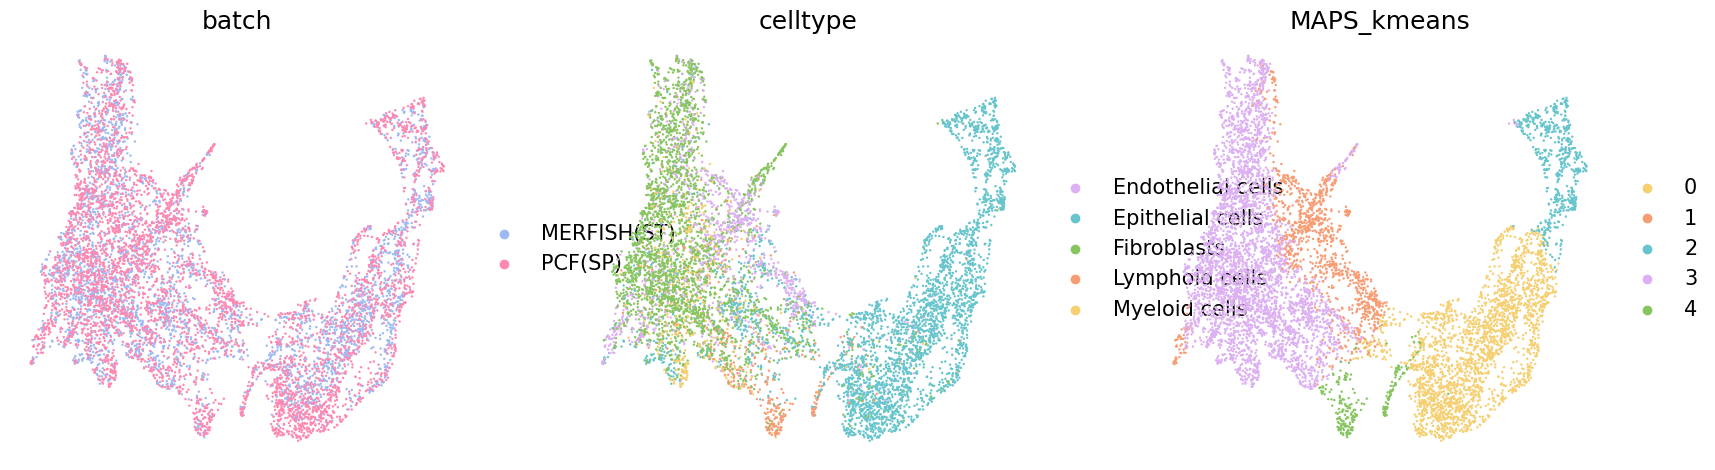

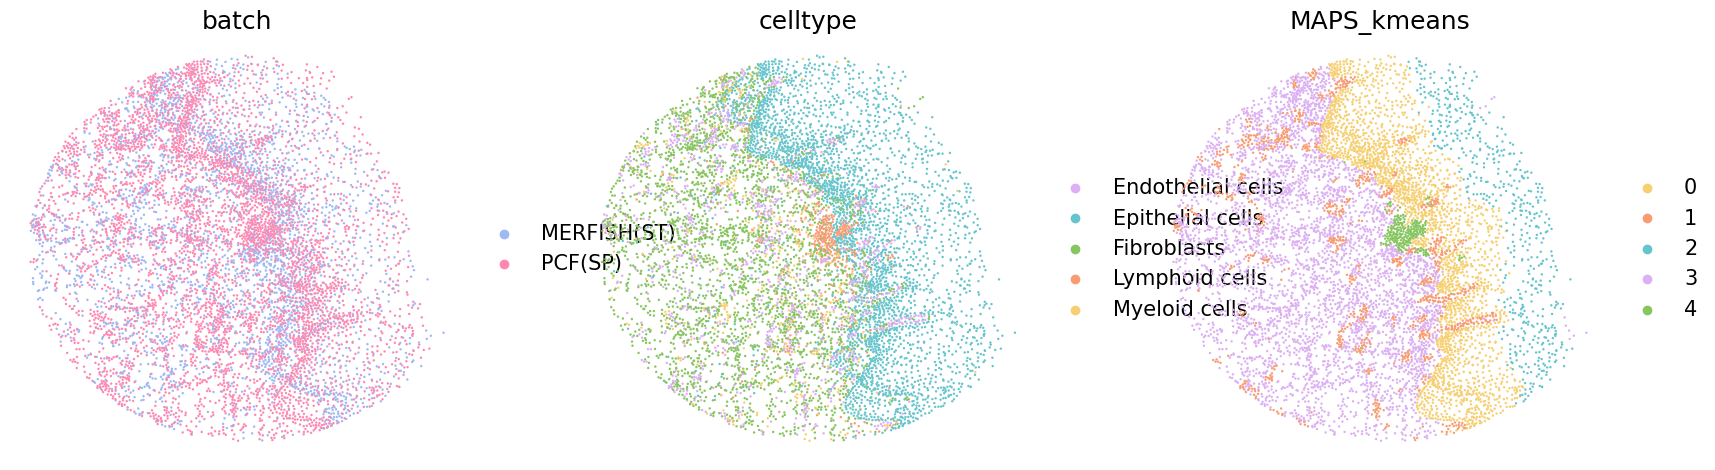

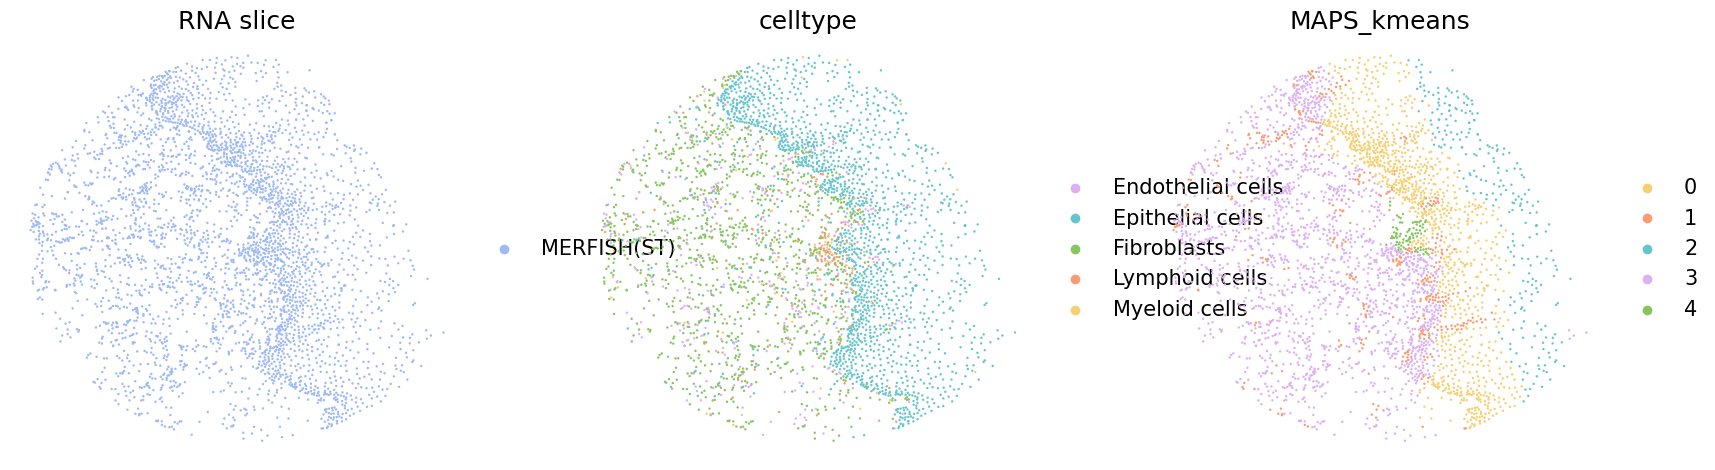

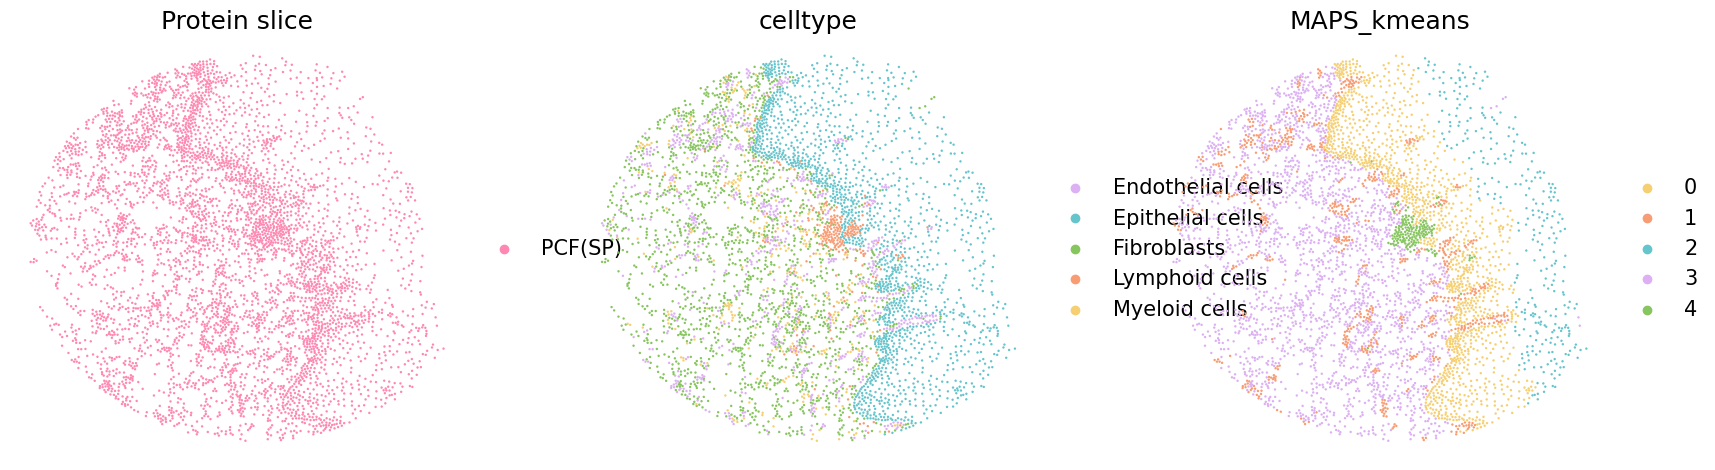

In [15]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15
color_dict1=create_new_color_dict(adata,cat_key='batch',skip_default_colors=5)
color_dict2=create_new_color_dict(adata,cat_key='celltype',skip_default_colors=0)
color_dict3=create_new_color_dict(adata,cat_key='MAPS_kmeans',skip_default_colors=0)
color_dict = color_dict1 | color_dict2 | color_dict3

source_adata.obs['MAPS_kmeans']=adata.obs['MAPS_kmeans']
target_adata.obs['MAPS_kmeans']=adata.obs['MAPS_kmeans']

sc.pl.umap(adata=adata,color=['batch','celltype','MAPS_kmeans'],size=12,frameon=False,palette=color_dict)
sc.pl.embedding(adata=adata,color=['batch','celltype','MAPS_kmeans'],basis='spatial',size=12,frameon=False,palette=color_dict)
sc.pl.embedding(adata=source_adata,color=['batch','celltype','MAPS_kmeans'],basis='spatial',title='RNA slice',size=12,frameon=False,palette=color_dict)
sc.pl.embedding(adata=target_adata,color=['batch','celltype','MAPS_kmeans'],basis='spatial',title='Protein slice',size=12,frameon=False,palette=color_dict)